# Ex10 — Interferometric microscopes: what the camera sees, and what comes back

Label-free microscopes record a scattered field through its interference with a reference, and a
reconstruction brings the field back. This example images the same polystyrene nanobeads with the
four interferometers gradix models, each a preset built on the coherent imaging element (§5.12):

| Microscope | Reference | Reconstruction |
|---|---|---|
| in-line (Gabor) holography | the unscattered light | `gx.recon.Inline`: back-propagation to the beads' plane |
| off-axis holography | a tilted beam from the laser | `gx.recon.OffAxis`: sideband demodulation |
| iSCAT | the coverslip's reflection | `gx.recon.ISCATContrast`: I/I_ref − 1 |
| QWLSI | none: four sheared copies of the field | `gx.recon.QWLSI`: harmonics, phase gradients, integration |

For each it shows the camera's frames, the reconstruction against the true field (`gx.out.Field`),
the noise a reconstruction propagates, and how much of the frames' information it keeps.

**Level** L4 presets and plans, L3 reconstructions · **Prerequisites** T1 · **Runtime** about
40 s on a GPU. `SMOKE` (set by the test suite) shrinks the frames, so the notebook also runs in
seconds on a CPU.

In [1]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

import gradix as gx

SMOKE = os.environ.get("GRADIX_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() and not SMOKE else "cpu"
F64 = torch.float64
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9})
MODALITIES = ("in-line", "off-axis", "iSCAT", "QWLSI")


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Return a CPU NumPy copy of a tensor, for plotting."""
    return t.detach().cpu().numpy()


def tensor(value: object) -> torch.Tensor:
    """Return a float64 tensor on the notebook's device."""
    return torch.as_tensor(value, dtype=F64, device=DEVICE)

## 1. The sample and the four microscopes

Three polystyrene beads (n = 1.59) of 100, 200 and 400 nm diameter lie in a row in water. The
transmission microscopes share an NA 0.8 objective and a camera of 6.5 µm pixels at 100×
(65 nm in the sample), with Poisson shot noise and 2 e⁻ of read noise. The illumination delivers
10⁵ photons/µm² per exposure, about 420 per pixel.

- **In-line**: the objective is focused 1.5 µm below the beads, so their holograms show rings.
- **Off-axis**: a reference beam as bright as the illumination, tilted so that its fringes sit
  on the frame's DFT grid (30 periods per axis). Its sideband lies beyond 3·NA from the origin,
  as off-axis holography needs.
- **iSCAT**: the beads rest on a coverslip (a `LayeredMedium`: water, glass, oil), under
  10⁷ photons/µm² of epi illumination through an NA 1.4 oil objective. The glass–water interface
  reflects 0.45 % of it back as the reference.
- **QWLSI**: a Hartmann grating 0.5 mm before the camera, with fringes of 4 camera pixels.

The presets return `gx.Microscope`s, and `gx.plan` routes the spheres to Mie scattering.

In [2]:
N = 32 if SMOKE else 96  # camera pixels per axis
WAVELENGTH, PIXEL, MAG = 0.532, 6.5, 100.0
pitch = PIXEL / MAG  # µm in the sample
camera = gx.Camera(
    pixel_size=PIXEL, shape=(N, N), noise=gx.noise.PoissonGaussian(read=2.0), unit="e"
)
diameters = torch.tensor([0.1, 0.2, 0.4], dtype=F64)
xs = torch.tensor([0.21, 0.5, 0.79], dtype=F64) * N * pitch  # three beads in a row, µm
y = 0.5 * N * pitch


def beads(z: torch.Tensor) -> gx.Spheres:
    """Return the three beads at heights z [3] µm (one image)."""
    position = torch.stack([xs, torch.full_like(xs, y), z], -1)[None, None]  # [1, 1, 3, 3]
    return gx.Spheres(
        position=position.to(DEVICE),
        radius=(diameters / 2)[None, None].to(DEVICE),
        material=tensor([[[1.59, 1.59, 1.59]]]),
    )


water = gx.Sample({"beads": beads(torch.zeros(3, dtype=F64))}, environment=gx.env.Homogeneous(1.33))
glass = gx.env.LayeredMedium(sample=1.33, coverslip=1.52, immersion=1.52)
on_glass = gx.Sample({"beads": beads(-diameters / 2 - 0.001)}, environment=glass)  # touching it

light = gx.light.PlaneWave(tensor(WAVELENGTH), irradiance=tensor(1e5))
objective = gx.Objective(NA=0.8, magnification=MAG)
cycles = N * 30 // 96  # the reference's fringe periods across the frame, per axis
tilt = math.asin(WAVELENGTH * cycles / (N * pitch) / MAG)  # its image-side angle, rad
microscopes = {
    "in-line": (
        water,
        gx.presets.InlineHolography(
            light=light, objective=objective.replace(focus=-1.5), camera=camera
        ),
    ),
    "off-axis": (
        water,
        gx.presets.OffAxisHolography(
            light=light,
            objective=objective,
            camera=camera,
            angle=tensor([tilt, tilt]),
            reference_irradiance=tensor(1e5),
        ),
    ),
    "iSCAT": (
        on_glass,
        gx.presets.ISCAT(
            light=gx.light.PlaneWave(tensor(WAVELENGTH), irradiance=tensor(1e7), travel=-1),
            objective=gx.Objective(NA=1.4, magnification=MAG),
            camera=camera,
        ),
    ),
    "QWLSI": (
        water,
        gx.presets.QWLSI(light=light, objective=objective, camera=camera, distance=500.0),
    ),
}
plans = {
    name: gx.plan(sample, scope, "standard", outputs=("expected", "image"))
    for name, (sample, scope) in microscopes.items()
}
chains = {name: plans[name].chain(*microscopes[name]) for name in MODALITIES}
print(plans["iSCAT"].pipeline.explain().splitlines()[0])

Pipeline 0d0e552c0eb9 · B≤1 · cuda:0 · float64/complex128/fp64-special/ieee · built in 1 ms


## 2. What the camera sees

Each plan renders the expected frames and a noisy image (top row). At 420 photons per pixel only
the 400 nm bead stands out in transmission, while iSCAT shows all three. The bottom row is each
bead's signature, the noiseless frame minus the frame without beads:

- in-line holography shows rings around each bead;
- off-axis holography shows the same field riding on the reference's fringes;
- iSCAT shows interferometric PSFs, whose centres turn dark or bright with the round-trip phase
  between backscatter and reflection (a height of λ/(4n) = 100 nm flips it);
- QWLSI shows the grating's grid of spots, displaced where the beads tilt the wavefront.

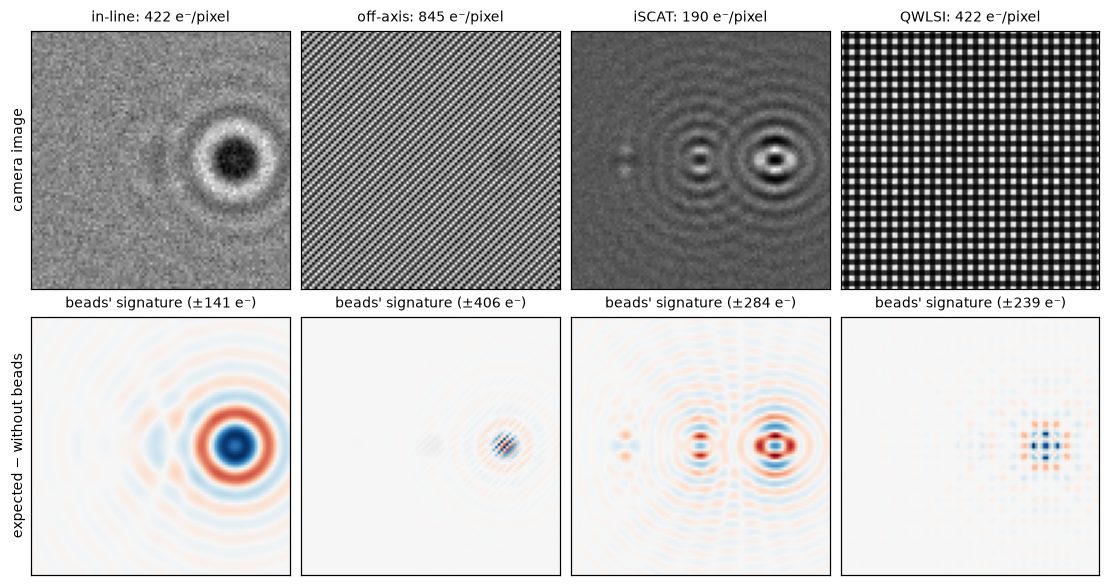

In [3]:
frames = {name: plans[name](*microscopes[name], key=7) for name in MODALITIES}
empty = {
    name: gx.recon.without_scatterers(chains[name])(outputs=("expected",)).expected
    for name in MODALITIES
}  # the frames without the beads
fig, axes = plt.subplots(2, 4, figsize=(10, 5.2), layout="constrained")
for col, name in enumerate(MODALITIES):
    image = to_numpy(frames[name].image[0, 0])
    axes[0, col].imshow(image, cmap="gray")
    axes[0, col].set_title(f"{name}: {image.mean():.0f} e⁻/pixel")
    signature = to_numpy(frames[name].expected[0, 0] - empty[name][0, 0])
    limit = np.abs(signature).max()
    axes[1, col].imshow(signature, cmap="RdBu_r", vmin=-limit, vmax=limit)
    axes[1, col].set_title(f"beads' signature (±{limit:.0f} e⁻)")
    for ax in axes[:, col]:
        ax.set_xticks([])
        ax.set_yticks([])
axes[0, 0].set_ylabel("camera image")
axes[1, 0].set_ylabel("expected − without beads")
plt.show()

## 3. Reconstructions against the true field

Every reconstruction has a `from_chain` constructor that reads the optics (pitch, wavelength, NA,
the reference's tilt, the grating) and renders its calibration from the Chain without its
scatterers, at the frames' precision. The true field comes from the same Chain as
`gx.out.Field(normalize="background")`: the image field over the unscattered one, at the pixel
centres, before any grating and without references. The in-line truth is rendered with the
objective focused on the beads, the plane the reconstruction propagates to.

A reconstruction can only return the band its window reads, so the comparison band-limits the
truth to that window. What remains is the reconstruction's own error: the twin image for in-line
holography, truncation for the others.

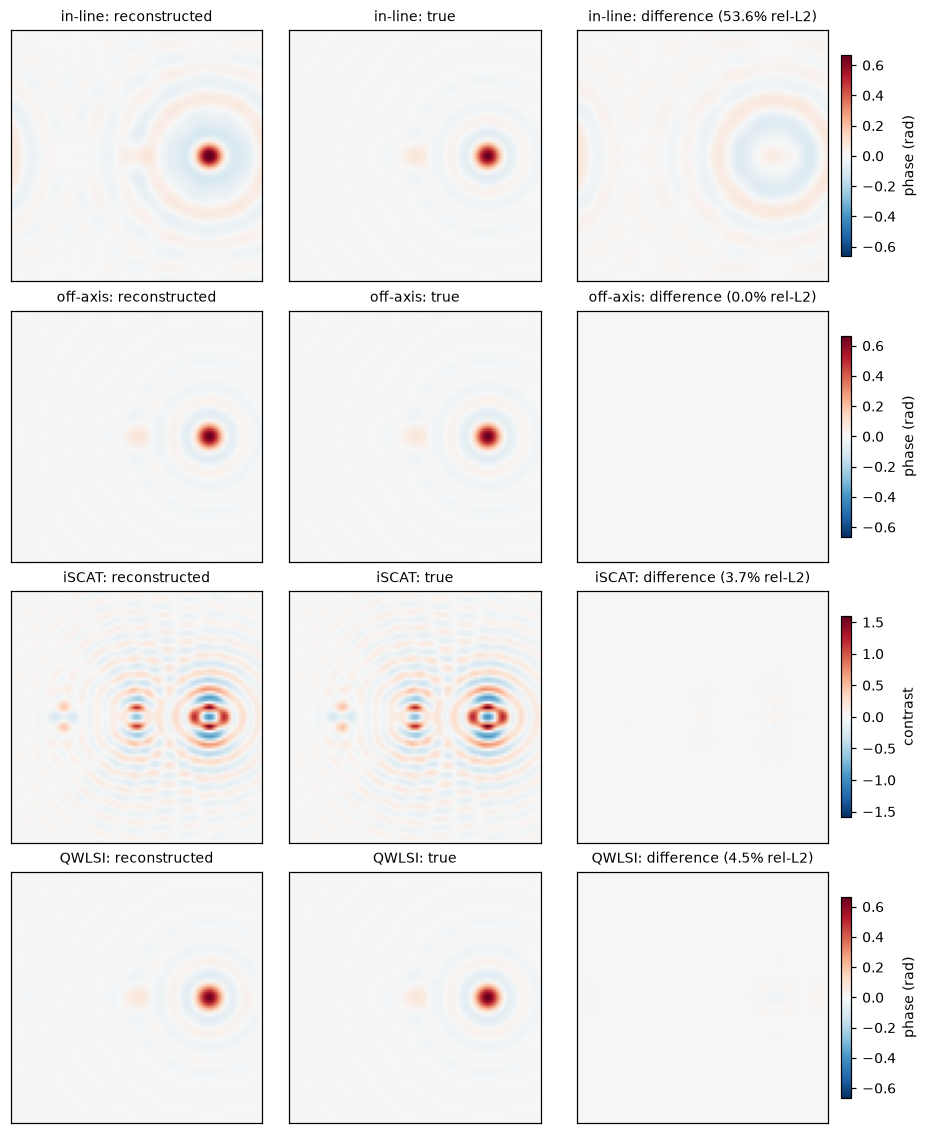

In [4]:
def band_limit(field: torch.Tensor, radius: float) -> torch.Tensor:
    """Keep a field's spatial frequencies within radius (cycles/µm), with a one-cell soft edge."""
    f = torch.fft.fftfreq(N, d=pitch, dtype=F64, device=field.device)
    cell = 1.0 / (N * pitch)
    edge = torch.clamp((radius - torch.sqrt(f[:, None] ** 2 + f[None, :] ** 2)) / cell + 0.5, 0, 1)
    return torch.fft.ifft2(torch.fft.fft2(field) * edge * edge * (3 - 2 * edge))


window = 0.8 / WAVELENGTH + 2.0 / (N * pitch)  # the pupil's band, the windows' default
recons = {
    "in-line": gx.recon.Inline.from_chain(chains["in-line"], distance=1.5, normalize=True, pad=0),
    "off-axis": gx.recon.OffAxis.from_chain(chains["off-axis"]),
    "iSCAT": gx.recon.ISCATContrast.from_chain(chains["iSCAT"]),
    "QWLSI": gx.recon.QWLSI.from_chain(chains["QWLSI"]),
}
field = gx.out.Field(normalize="background")
in_focus = gx.tree.replace(chains["in-line"], {"imaging.objective.focus": 0.0})
truths = {
    "in-line": in_focus(outputs={"E": field}).E[0, 0],
    "off-axis": chains["off-axis"](outputs={"E": field}).E[0, 0],
    "QWLSI": chains["QWLSI"](outputs={"E": field}).E[0, 0],
}
iscat_truth = chains["iSCAT"](outputs={"E": field}).E[0, 0]  # the field over the reflection
results = {name: recons[name](frames[name].expected)[0, 0] for name in MODALITIES}

fig, axes = plt.subplots(4, 3, figsize=(8.4, 10.2), layout="constrained")
inner = slice(N // 8, N - N // 8)  # away from the frame's periodic edges
for row, name in enumerate(MODALITIES):
    if name == "iSCAT":
        got = results[name]
        want = iscat_truth.abs() ** 2 - 1  # the contrast of the true field, |E/E_r|² − 1
        label = "contrast"
    else:
        radius = window if name != "QWLSI" else min(window, 0.5 * MAG / (4 * PIXEL))
        got = torch.angle(results[name])
        want = torch.angle(band_limit(truths[name].to(torch.complex128), radius))
        got, want = got - got[inner, inner].mean(), want - want[inner, inner].mean()
        label = "phase (rad)"
    error = float((got - want)[inner, inner].norm() / want[inner, inner].norm())
    limit = float(want.abs().max())
    for col, (image, title) in enumerate(
        ((got, "reconstructed"), (want, "true"), (got - want, f"difference ({error:.1%} rel-L2)"))
    ):
        shown = axes[row, col].imshow(to_numpy(image), cmap="RdBu_r", vmin=-limit, vmax=limit)
        axes[row, col].set_title(f"{name}: {title}")
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
    fig.colorbar(shown, ax=axes[row, 2], shrink=0.8, label=label)
plt.show()

- **Off-axis** recovers the window-limited field to well under 0.1 %.
- **QWLSI** comes within a few percent. The 400 nm bead's 0.6 rad of phase is beyond the weak
  object its integration assumes, and the harmonic windows are narrower than the pupil.
- **In-line** reconstruction carries Gabor's twin image: the conjugate term, defocused by twice
  the distance, rings around every bead. Its model, h = I/I_b − 1 ≈ 2Re(E_s/E_b), also
  assumes weak scatterers, which the 400 nm bead is not.
- **iSCAT**'s contrast is a pointwise function of the frame. What remains is the camera: pixels
  average the intensity over their area, while the true field is sampled at their centres, and
  the NA 1.4 PSF has structure on the scale of a pixel.

## 4. The noise each reconstruction propagates

Reconstructing the noisy images shows what the photon budget leaves. The phase noise away from
the beads is the noise floor that a fit or a network reading these fields works against.

iSCAT contrast of the 100 nm bead: -0.255 to +0.434 within ±3 pixels
iSCAT contrast of the 200 nm bead: -0.599 to +1.170 within ±3 pixels
iSCAT contrast of the 400 nm bead: -0.899 to +1.515 within ±3 pixels


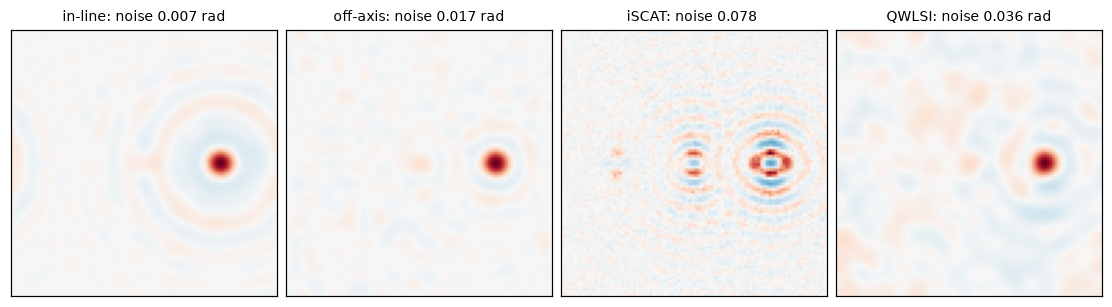

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2.8), layout="constrained")
for ax, name in zip(axes, MODALITIES, strict=True):
    noisy = recons[name](frames[name].image)[0, 0]
    shown = noisy if name == "iSCAT" else torch.angle(noisy)
    floor = float(shown[: N // 8, : N // 8].std())  # a corner without beads
    limit = float(shown.abs().max())
    ax.imshow(to_numpy(shown), cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(f"{name}: noise {floor:.3f} {'' if name == 'iSCAT' else 'rad'}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()
contrast = recons["iSCAT"](frames["iSCAT"].expected)[0, 0]
for d, x in zip(diameters.tolist(), xs.tolist(), strict=True):
    col = int(x / pitch)  # the pixel holding the bead's centre
    near = contrast[N // 2 - 3 : N // 2 + 4, max(col - 3, 0) : col + 4]
    print(
        f"iSCAT contrast of the {1e3 * d:.0f} nm bead: {float(near.min()):+.3f} to "
        f"{float(near.max()):+.3f} within ±3 pixels"
    )

## 5. How much of the frames' information a reconstruction keeps

A reconstruction's windows discard part of what the camera recorded. `gx.crlb` measures what is
left: with `reconstruction=R` it returns the Cramér–Rao bound of R's output under the camera noise
R propagates (ADR-44). Here, the bound on the 100 nm bead's radius, with its index known:

In [6]:
for name in MODALITIES:
    pipe = plans[name].pipeline
    chain = chains[name]
    raw = gx.crlb(pipe, chain, wrt="beads.radius")["beads.radius"][0, 0, 0]
    kept = gx.crlb(pipe, chain, wrt="beads.radius", reconstruction=recons[name])
    through = type(recons[name]).__name__
    print(
        f"{name:9s} raw frames σ_r = {1e3 * float(raw):.4f} nm, through {through:13s}"
        f" σ_r = {1e3 * float(kept['beads.radius'][0, 0, 0]):.4f} nm"
    )

in-line   raw frames σ_r = 8.7505 nm, through Inline        σ_r = 8.7777 nm
off-axis  raw frames σ_r = 15.7293 nm, through OffAxis       σ_r = 16.6204 nm
iSCAT     raw frames σ_r = 0.6652 nm, through ISCATContrast σ_r = 0.6652 nm
QWLSI     raw frames σ_r = 22.5260 nm, through QWLSI         σ_r = 28.6963 nm


- **iSCAT**'s contrast is pointwise and keeps everything. Its far smaller bound owes much to its
  100-fold brighter illumination: the reflection returns only 0.45 % of it.
- **In-line** holography's back-propagation keeps nearly everything within the pupil's band.
- **Off-axis** holography's window keeps the sideband but discards the beads' in-line
  interference with the unscattered light, which the raw frames also hold.
- **QWLSI**'s harmonic windows lose part of both.

Ex11 designs the illumination for what each reconstruction keeps, for the radius and the index
together, where small beads are hard.

**Where next.** Ex11 (light shaping for nanobead characterisation); §5.12 of the architecture
document for the models and their accuracy.